# Train a Deep Learning model with the timeseries data


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler

import json

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from core.matlab_data_loader import MatlabDataLoader

from pathlib import Path

import core.constants as c

RANDOM_STATE = 42
RANDOM_STATE_2 = 6
np.random.seed(RANDOM_STATE)
MODEL_NAME = "alt-v1"

In [2]:
RESULTS_DIR = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'

all_sessions_matrix = np.load(RESULTS_DIR / 'timeseries_matrix.npy')
with open(RESULTS_DIR / 'timeseries_channels.json', 'r') as f:
    channels = json.load(f)
with open(RESULTS_DIR / 'timeseries_sessions.json', 'r') as f:
    valid_session_ids = json.load(f)

print("Shape of the timeseries matrix: ", all_sessions_matrix.shape)
print("Number of channels: ", len(channels))
print("Number of sessions: ", len(valid_session_ids))

for channel in channels:
    print(channel)

Shape of the timeseries matrix:  (1813, 101, 48)
Number of channels:  48
Number of sessions:  1813
L_ankle_angle_X
L_ankle_angle_Y
L_ankle_angle_Z
L_ankle_velocity_X
L_ankle_velocity_Y
L_ankle_velocity_Z
L_foot_angle_X
L_foot_angle_Y
L_foot_angle_Z
L_foot_velocity_X
L_foot_velocity_Y
L_foot_velocity_Z
L_hip_angle_X
L_hip_angle_Y
L_hip_angle_Z
L_hip_velocity_X
L_hip_velocity_Y
L_hip_velocity_Z
L_knee_angle_X
L_knee_angle_Y
L_knee_angle_Z
L_knee_velocity_X
L_knee_velocity_Y
L_knee_velocity_Z
R_ankle_angle_X
R_ankle_angle_Y
R_ankle_angle_Z
R_ankle_velocity_X
R_ankle_velocity_Y
R_ankle_velocity_Z
R_foot_angle_X
R_foot_angle_Y
R_foot_angle_Z
R_foot_velocity_X
R_foot_velocity_Y
R_foot_velocity_Z
R_hip_angle_X
R_hip_angle_Y
R_hip_angle_Z
R_hip_velocity_X
R_hip_velocity_Y
R_hip_velocity_Z
R_knee_angle_X
R_knee_angle_Y
R_knee_angle_Z
R_knee_velocity_X
R_knee_velocity_Y
R_knee_velocity_Z


In [3]:
loader = MatlabDataLoader()

session_data = loader.get_session_data_full_cleaned().set_index("id")
metadata_columns = ["age", "Height", "Weight", "Gender", "DominantLeg", "speed_r"]
metadata = session_data[metadata_columns]
complete_metadata = metadata.dropna()

num_complete_rows = complete_metadata.shape[0]
print(f"\nNumber of rows with a value for all metadata columns: {num_complete_rows}")
complete_metadata.info(verbose=True)



Number of rows with a value for all metadata columns: 1476
<class 'pandas.core.frame.DataFrame'>
Index: 1476 entries, 100560_20120717T103748 to 201099_20150414T092041
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1476 non-null   float64
 1   Height       1476 non-null   float64
 2   Weight       1476 non-null   float64
 3   Gender       1476 non-null   object 
 4   DominantLeg  1476 non-null   object 
 5   speed_r      1476 non-null   float64
dtypes: float64(4), object(2)
memory usage: 80.7+ KB


In [4]:
# Compare valid_session_ids against sessions with complete metadata
session_ids = set(session_data.index.astype(str))
valid_ids = set(map(str, valid_session_ids))
intersection_ids = valid_ids & session_ids
complete_ids = set(complete_metadata.index.astype(str))
complete_intersection_ids = complete_ids & valid_ids

print(f"Number of sessions: {len(session_ids)}")
print(f"Number of time-series sessions: {len(valid_ids)}")
print(f"Number of sessions with complete metadata: {len(complete_ids)}")
print(f"Number of sessions present both in metadata and time-series: {len(intersection_ids)}")
print(f"Number of sessions with complete metadata and present in time-series: {len(complete_intersection_ids)}")
print(f"We loose {(1-(len(complete_intersection_ids) / len(valid_ids)))*100:.2f}% of the data due to missing metadata.")

Number of sessions: 1832
Number of time-series sessions: 1813
Number of sessions with complete metadata: 1476
Number of sessions present both in metadata and time-series: 1812
Number of sessions with complete metadata and present in time-series: 1456
We loose 19.69% of the data due to missing metadata.


In [5]:
metadata_common = complete_metadata.loc[list(complete_intersection_ids)]
metadata_common

,age,Height,Weight,Gender,DominantLeg,speed_r
id,,,,,,
101416_20150409T123643,34.0,155.0,51.1,female,right,2.187539
100265_20110328T232447,46.0,179.1,85.2,male,right,2.688086
200345_20140912T073153,42.0,192.0,93.0,male,right,3.659127
100516_20120524T093827,56.0,186.1,93.1,male,left,2.494803
101696_20160310T095120,51.0,174.0,65.1,male,right,2.161294
...,...,...,...,...,...,...
100680_20130117T100723,27.0,171.6,66.5,male,right,2.722587
101083_20140502T125436,41.0,182.0,81.9,male,right,2.717378
101344_20141118T181554,56.0,180.0,82.2,male,left,2.345033


In [6]:
filtered_indices = [i for i, sid in enumerate(valid_session_ids) if sid in complete_intersection_ids]
sessions_matrix_common = all_sessions_matrix[filtered_indices]
sessions_matrix_common.shape
type(sessions_matrix_common)

numpy.ndarray

In [7]:
is_injured_common = session_data.loc[list(complete_intersection_ids), 'is_injured']
is_injured_common

id
101416_20150409T123643     True
100265_20110328T232447    False
200345_20140912T073153     True
100516_20120524T093827    False
101696_20160310T095120     True
                          ...  
100680_20130117T100723    False
101083_20140502T125436     True
101344_20141118T181554    False
100792_20130711T114924    False
100700_20130227T101208     True
Name: is_injured, Length: 1456, dtype: bool

In [8]:
subject_id_common = session_data.loc[list(complete_intersection_ids), 'sub_id']
subject_id_common

id
101416_20150409T123643    101416
100265_20110328T232447    100265
200345_20140912T073153    200345
100516_20120524T093827    100516
101696_20160310T095120    101696
                           ...  
100680_20130117T100723    100680
101083_20140502T125436    101083
101344_20141118T181554    101344
100792_20130711T114924    100792
100700_20130227T101208    100700
Name: sub_id, Length: 1456, dtype: int64

In [9]:
# Class imbalance:
is_injured_common.value_counts(normalize=True)

is_injured
True     0.727335
False    0.272665
Name: proportion, dtype: float64

In [10]:
# N = 1456 -- Sessions with complete metadata and present in time-series.
X_ts: np.ndarray = sessions_matrix_common  #  (N, 101, 54)
X_meta: pd.DataFrame = metadata_common  # (N, 6)
y: pd.Series = is_injured_common  # (N,)
subject_id: pd.Series = subject_id_common  # (N,)

In [11]:
# Handle metadata preprocessing (one-hot encoding for categorical variables)
import pandas as pd

print("=== METADATA PREPROCESSING ===")
print("Original metadata columns:", X_meta.columns.tolist())
print("Original metadata shape:", X_meta.shape)

# One-hot encode categorical variables
X_meta_encoded = pd.get_dummies(X_meta, columns=['Gender', 'DominantLeg'], drop_first=False)
print("After one-hot encoding:", X_meta_encoded.columns.tolist())
print("New metadata shape:", X_meta_encoded.shape)

# Update the values array
X_meta_values = X_meta_encoded.values.astype(np.float32)
meta_feature_names = X_meta_encoded.columns.tolist()

print(f"Final metadata shape: {X_meta_values.shape}")
print(f"Feature names: {meta_feature_names}")


=== METADATA PREPROCESSING ===
Original metadata columns: ['age', 'Height', 'Weight', 'Gender', 'DominantLeg', 'speed_r']
Original metadata shape: (1456, 6)
After one-hot encoding: ['age', 'Height', 'Weight', 'speed_r', 'Gender_female', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']
New metadata shape: (1456, 9)
Final metadata shape: (1456, 9)
Feature names: ['age', 'Height', 'Weight', 'speed_r', 'Gender_female', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']


In [12]:
# Step 1: Data Exploration and Preprocessing
print("=== DATA OVERVIEW ===")
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Metadata shape: {X_meta_values.shape}")  # (N, metadata_features)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")
print(f"Missing values in metadata: {np.isnan(X_meta_values).sum()}")

# Basic statistics
print(f"\nTimeseries stats:")
print(f"  Min: {X_ts.min():.3f}, Max: {X_ts.max():.3f}")
print(f"  Mean: {X_ts.mean():.3f}, Std: {X_ts.std():.3f}")

print(f"\nMetadata stats:")
print(f"  Min: {X_meta_values.min():.3f}, Max: {X_meta_values.max():.3f}")
print(f"  Mean: {X_meta_values.mean():.3f}, Std: {X_meta_values.std():.3f}")


=== DATA OVERVIEW ===
Timeseries shape: (1456, 101, 48)
Metadata shape: (1456, 9)
Labels shape: (1456,)
Subject IDs shape: (1456,)

Class distribution:
  Class 0: 397 samples (27.3%)
  Class 1: 1059 samples (72.7%)

Missing values in timeseries: 0
Missing values in metadata: 0

Timeseries stats:
  Min: -11442.526, Max: 6956.552
  Mean: -0.929, Std: 113.039

Metadata stats:
  Min: 0.000, Max: 196.500
  Mean: 31.827, Std: 55.333


In [13]:
# Step 1: Data Exploration and Preprocessing
print("=== DATA OVERVIEW ===")
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Metadata shape: {X_meta.shape}")  # (N, metadata_features)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")
print(f"Missing values in metadata: {X_meta.isna().any(axis=1).sum()}")


=== DATA OVERVIEW ===
Timeseries shape: (1456, 101, 48)
Metadata shape: (1456, 6)
Labels shape: (1456,)
Subject IDs shape: (1456,)

Class distribution:
  Class 0: 397 samples (27.3%)
  Class 1: 1059 samples (72.7%)

Missing values in timeseries: 0
Missing values in metadata: 0


In [14]:
# Step 2: Data Preprocessing

# Reshape for scaling: (N*101, 48) -> scale -> reshape back to (N, 101, 48)
N, T, C = X_ts.shape
X_ts_reshaped = X_ts.reshape(-1, C)
scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts_reshaped).reshape(N, T, C).astype(np.float32)

# Normalize metadata
scaler_meta = StandardScaler()
X_meta_scaled = scaler_meta.fit_transform(X_meta_values).astype(np.float32)

print("=== AFTER PREPROCESSING ===")
print(f"Timeseries scaled stats:")
print(f"  Min: {X_ts_scaled.min():.3f}, Max: {X_ts_scaled.max():.3f}")
print(f"  Mean: {X_ts_scaled.mean():.3f}, Std: {X_ts_scaled.std():.3f}")

print(f"\nMetadata scaled stats:")
print(f"  Min: {X_meta_scaled.min():.3f}, Max: {X_meta_scaled.max():.3f}")
print(f"  Mean: {X_meta_scaled.mean():.3f}, Std: {X_meta_scaled.std():.3f}")


=== AFTER PREPROCESSING ===
Timeseries scaled stats:
  Min: -99.506, Max: 67.621
  Mean: -0.000, Std: 1.000

Metadata scaled stats:
  Min: -5.607, Max: 38.144
  Mean: -0.000, Std: 1.000


In [15]:
# Step 3: Train-Test Split with Subject-level Splitting
# Important: Ensure no subject appears in both train and test sets

unique_subjects = np.unique(subject_id)
print(f"Total unique subjects: {len(unique_subjects)}")

# Use GroupShuffleSplit to ensure subject-level separation
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X_ts_scaled, y, groups=subject_id))

# Split the data
X_ts_train, X_ts_test = X_ts_scaled[train_idx], X_ts_scaled[test_idx]
X_meta_train, X_meta_test = X_meta_scaled[train_idx], X_meta_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]

print(f"\n=== TRAIN-TEST SPLIT ===")
print(f"Training set: {len(train_idx)} sessions from {len(np.unique(subject_train))} subjects")
print(f"Test set: {len(test_idx)} sessions from {len(np.unique(subject_test))} subjects")

# Verify no subject overlap
subject_overlap = set(subject_train) & set(subject_test)
print(f"Subject overlap: {len(subject_overlap)} (should be 0)")

# Check class distribution in splits
train_counts = np.bincount(y_train.astype(int))
test_counts = np.bincount(y_test.astype(int))
print(f"\nTrain class distribution: {train_counts} ({train_counts/len(y_train)*100}%)")
print(f"Test class distribution: {test_counts} ({test_counts/len(y_test)*100}%)")


Total unique subjects: 1185

=== TRAIN-TEST SPLIT ===
Training set: 1168 sessions from 948 subjects
Test set: 288 sessions from 237 subjects
Subject overlap: 0 (should be 0)

Train class distribution: [323 845] ([27.65410959 72.34589041]%)
Test class distribution: [ 74 214] ([25.69444444 74.30555556]%)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_47315/56564008.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_47315/56564008.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]


In [16]:
# Step 4: Handle Class Imbalance
# Calculate class weights to handle the 70-30 imbalance

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"=== CLASS WEIGHTS ===")
print(f"Class weights: {class_weight_dict}")
print(f"This will penalize misclassifying the minority class more heavily")


=== CLASS WEIGHTS ===
Class weights: {0: np.float64(1.8080495356037152), 1: np.float64(0.6911242603550296)}
This will penalize misclassifying the minority class more heavily


In [ ]:
X_ts_train, X_ts_test = X_ts_scaled[train_idx], X_ts_scaled[test_idx]
X_meta_train, X_meta_test = X_meta_scaled[train_idx], X_meta_scaled[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]

NameError: name 'ascasc' is not defined

In [ ]:
# Step 5: Build the Deep Learning Model
# Hybrid architecture: CNN+LSTM for timeseries + Dense layers for metadata

def create_model(ts_shape, meta_shape):
    # Time-series tower
    ts_in = keras.Input(shape=ts_shape, name="ts")
    x = layers.Bidirectional(layers.LSTM(32))(ts_in)   # small & fast
    x = layers.Dropout(0.2)(x)

    # Optional metadata tower
    meta_in = keras.Input(shape=meta_shape, name="meta")
    m = layers.Dense(16, activation="relu")(meta_in)
    m = layers.Dropout(0.1)(m)
    z = layers.Concatenate()([x, m])
    inputs = [ts_in, meta_in]

    # Head
    z = layers.Dense(32, activation="relu")(z)
    out = layers.Dense(1, activation="sigmoid", name="out")(z)

    model = keras.Model(inputs=inputs, outputs=out, name="simple_bilstm_baseline")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"),
                 keras.metrics.AUC(name="pr_auc", curve="PR"),
                 "accuracy"]
    )
    return model



# Create the model
model = create_model(ts_shape=(101, 48), meta_shape=(9,))

model.summary()

Model: "simple_bilstm_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ts (InputLayer)     │ (None, 101, 48)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta (InputLayer)   │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     20,736 │ ts[0][0]          │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        160 │ meta[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,521 (91.88 KB)

 Trainable params: 23,521 (91.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Step 6: Compile the Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("Model compiled successfully!")


Model compiled successfully!


In [ ]:
# Step 7: Set up Training Callbacks
from pathlib import Path

# Create results directory
RESULTS_DIR = Path(c.RICKD_PROCESSED_DATA_FOLDER).parent / 'results' / 'models' / 'deep_learning'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Define callbacks
callbacks = [
    # Early stopping to prevent overfitting
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Save best model
    ModelCheckpoint(
        filepath=str(RESULTS_DIR / f'best_{MODEL_NAME}_model.h5'),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print(f"Callbacks configured. Models will be saved to: {RESULTS_DIR}")


Callbacks configured. Models will be saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning


In [ ]:
# Step 8: Create Validation Split
# Further split training data for validation (80% train, 20% val from training set)

val_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE_2)
train_val_idx, val_idx = next(val_splitter.split(X_ts_train, y_train, groups=subject_train))

# Create validation split
X_ts_train_final = X_ts_train[train_val_idx]
X_meta_train_final = X_meta_train[train_val_idx]
y_train_final = y_train[train_val_idx]

X_ts_val = X_ts_train[val_idx]
X_meta_val = X_meta_train[val_idx]
y_val = y_train[val_idx]

print(f"=== FINAL DATA SPLITS ===")
print(f"Training: {len(X_ts_train_final)} sessions")
print(f"Validation: {len(X_ts_val)} sessions")
print(f"Test: {len(X_ts_test)} sessions")

# Verify no subject overlap between final train and val
subject_train_final = subject_train[train_val_idx]
subject_val = subject_train[val_idx]
overlap = set(subject_train_final) & set(subject_val)
print(f"Train-Val subject overlap: {len(overlap)} (should be 0)")


=== FINAL DATA SPLITS ===
Training: 942 sessions
Validation: 226 sessions
Test: 288 sessions
Train-Val subject overlap: 0 (should be 0)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_46437/3304217128.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train_final = y_train[train_val_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_46437/3304217128.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_val = y_train[val_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_46437/3304217128.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `se

In [ ]:
# Step 9: Train the Model
print("=== STARTING TRAINING ===")
print("This may take several minutes depending on your hardware...")

# Set random seeds for reproducibility
tf.random.set_seed(RANDOM_STATE)

history = model.fit(
    x=[X_ts_train_final, X_meta_train_final],
    y=y_train_final,
    validation_data=([X_ts_val, X_meta_val], y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")


=== STARTING TRAINING ===
This may take several minutes depending on your hardware...
Epoch 1/100
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6274 - loss: 0.7039 - precision: 0.7397 - recall: 0.7511
Epoch 1: val_loss improved from None to 0.76972, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_alt-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5308 - loss: 0.7099 - precision: 0.7295 - recall: 0.5425 - val_accuracy: 0.3540 - val_loss: 0.7697 - val_precision: 0.7500 - val_recall: 0.2414 - learning_rate: 0.0010
Epoch 2/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5351 - loss: 0.6759 - precision: 0.8244 - recall: 0.4700
Epoch 2: val_loss improved from 0.76972 to 0.73852, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_alt-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5732 - loss: 0.6841 - precision: 0.7905 - recall: 0.5455 - val_accuracy: 0.3805 - val_loss: 0.7385 - val_precision: 0.7429 - val_recall: 0.2989 - learning_rate: 0.0010
Epoch 3/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5260 - loss: 0.6671 - precision: 0.8053 - recall: 0.4630
Epoch 3: val_loss did not improve from 0.73852
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5796 - loss: 0.6695 - precision: 0.8090 - recall: 0.5365 - val_accuracy: 0.4292 - val_loss: 0.7409 - val_precision: 0.7922 - val_recall: 0.3506 - learning_rate: 0.0010
Epoch 4/100
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5657 - loss: 0.6498 - precision: 0.8452 - recall: 0.5001
Epoch 4: val_loss did not improve from 0.73852
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6178 - loss: 0.6449 - precision: 0.8316 - recall: 0.5812 - val_accuracy: 0.4602 - val_loss: 0.7399 - val_precision: 0.7766 - val_recall: 0.4195 - learning_rate: 0

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7219 - loss: 0.5557 - precision: 0.8880 - recall: 0.6975 - val_accuracy: 0.5487 - val_loss: 0.7315 - val_precision: 0.7769 - val_recall: 0.5805 - learning_rate: 0.0010
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7065 - loss: 0.5220 - precision: 0.8908 - recall: 0.6813
Epoch 8: val_loss improved from 0.73148 to 0.73030, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_alt-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7314 - loss: 0.5194 - precision: 0.8929 - recall: 0.7079 - val_accuracy: 0.6062 - val_loss: 0.7303 - val_precision: 0.7972 - val_recall: 0.6552 - learning_rate: 0.0010
Epoch 9/100
28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7439 - loss: 0.5036 - precision: 0.8977 - recall: 0.7331
Epoch 9: val_loss improved from 0.73030 to 0.69974, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/best_alt-v1_model.h5


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7590 - loss: 0.4882 - precision: 0.9066 - recall: 0.7377 - val_accuracy: 0.6018 - val_loss: 0.6997 - val_precision: 0.7658 - val_recall: 0.6954 - learning_rate: 0.0010
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7686 - loss: 0.4641 - precision: 0.8934 - recall: 0.7753
Epoch 10: val_loss did not improve from 0.69974
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7919 - loss: 0.4500 - precision: 0.9159 - recall: 0.7794 - val_accuracy: 0.5752 - val_loss: 0.7716 - val_precision: 0.7786 - val_recall: 0.6264 - learning_rate: 0.0010
Epoch 11/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8174 - loss: 0.4088 - precision: 0.9341 - recall: 0.8062
Epoch 11: val_loss did not improve from 0.69974
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8174 - loss: 0.4176 - precision: 0.9309 - recall: 0.8033 - val_accuracy: 0.5841 - val_loss: 0.8069 - val_precision: 0.7899 - val_recall: 0.6264 - learning_rat

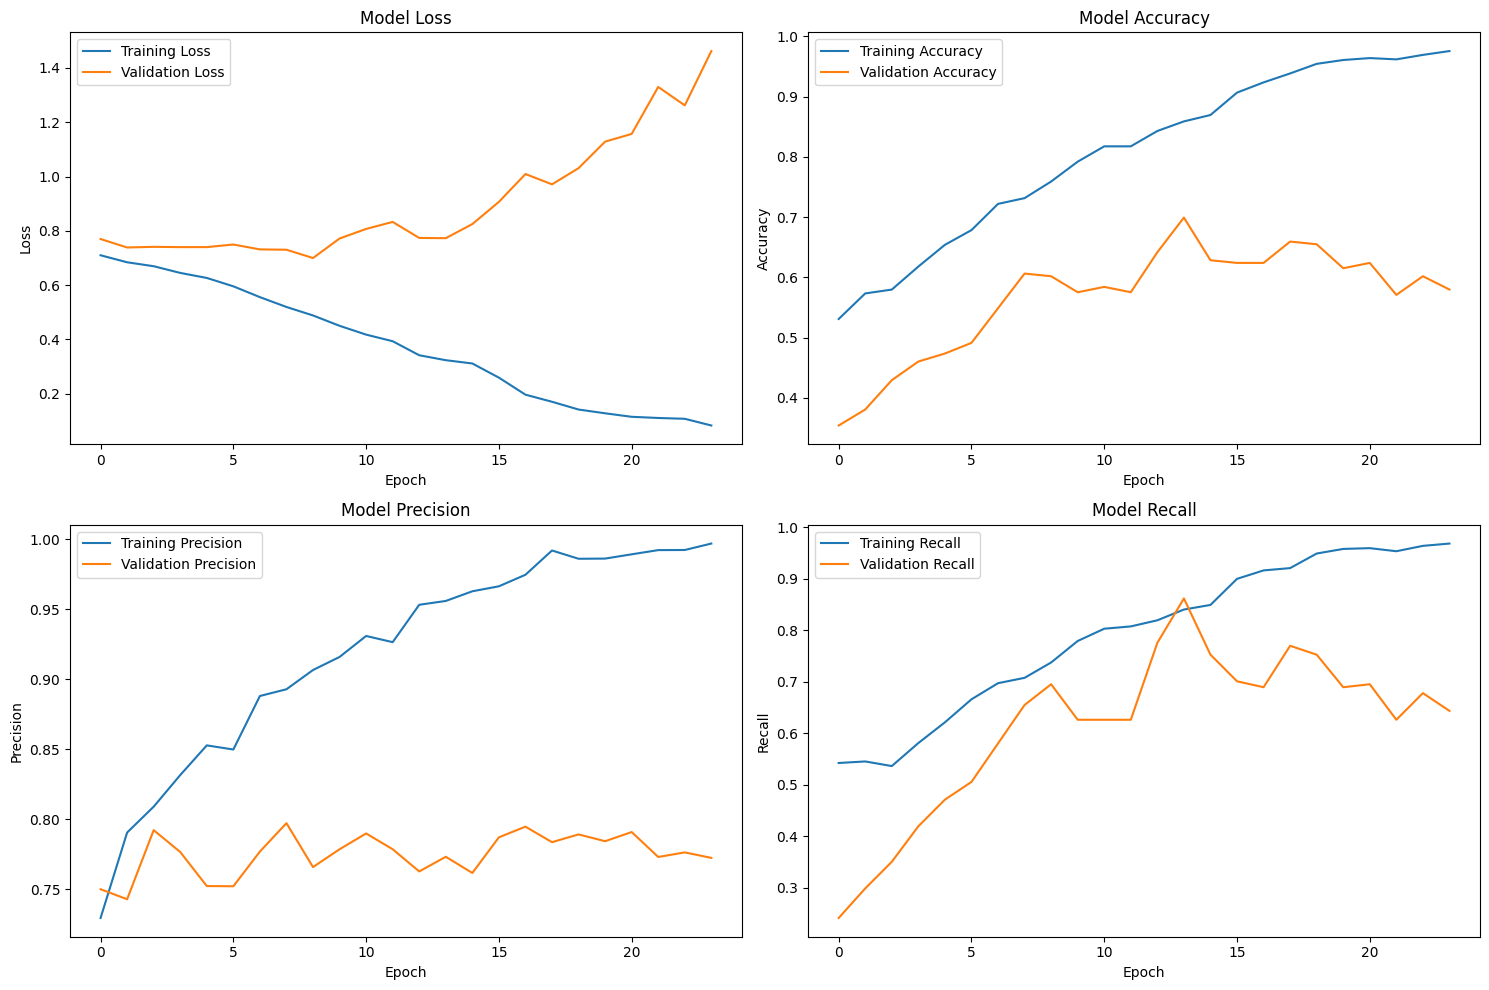

Training history plot saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/training_history.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 10: Plot Training History
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Model Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Precision
axes[1, 0].plot(history.history['precision'], label='Training Precision')
axes[1, 0].plot(history.history['val_precision'], label='Validation Precision')
axes[1, 0].set_title('Model Precision')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()

# Recall
axes[1, 1].plot(history.history['recall'], label='Training Recall')
axes[1, 1].plot(history.history['val_recall'], label='Validation Recall')
axes[1, 1].set_title('Model Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Save the plot
plt.savefig(RESULTS_DIR / f'training_history_{MODEL_NAME}.png', dpi=300, bbox_inches='tight')
print(f"Training history plot saved to: {RESULTS_DIR / 'training_history.png'}")


In [ ]:
# model = keras.models.load_model(RESULTS_DIR / f"best_{MODEL_NAME}_model.h5")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Test Loss: 0.7533
Test Accuracy: 0.5556
Test Precision: 0.7389
Test Recall: 0.6215
Test AUC: 0.5166
              precision    recall  f1-score   support

 Not Injured       0.25      0.36      0.30        74
     Injured       0.74      0.62      0.68       214

    accuracy                           0.56       288
   macro avg       0.49      0.49      0.49       288
weighted avg       0.61      0.56      0.58       288


F1 Score: 0.6751


<Figure size 640x480 with 0 Axes>

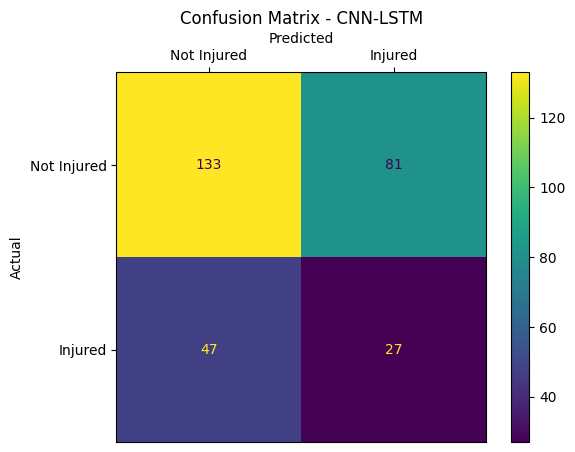

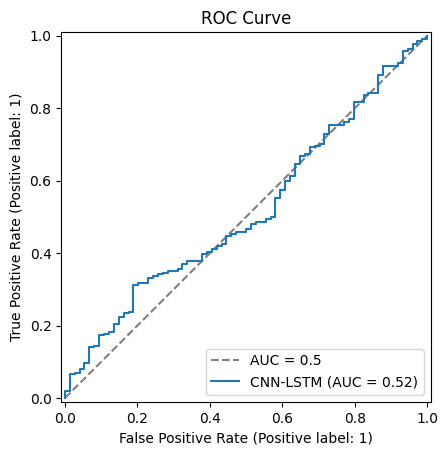

In [ ]:
# Step 11: Evaluate on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay

MODEL_NAME = "CNN-LSTM"

def plot_confusion_matrix(y_true, y_pred, labels):
    plt.figure()
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_true, 
        y_pred, 
        display_labels=labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {MODEL_NAME}')

def plot_roc_curve(y_true, y_pred_proba):
    plt.figure()
    ax = plt.gca()
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

    roc_disp = RocCurveDisplay.from_predictions(
        y_true, 
        y_pred_proba, 
        name=MODEL_NAME,
        ax=ax,
    )
    roc_disp.ax_.set_title('ROC Curve')

# Make predictions on test set
y_pred_proba = model.predict([X_ts_test, X_meta_test])
THRESHOLD = 0.5
y_pred = (y_pred_proba > THRESHOLD).astype(int).flatten()

# Calculate metrics
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    [X_ts_test, X_meta_test], y_test, verbose=0
)

auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test AUC: {auc_score:.4f}")

# Detailed classification report
print(classification_report(y_test, y_pred, target_names=['Not Injured', 'Injured']))

# Confusion Matrix
plot_confusion_matrix(y_test, y_pred, labels=['Not Injured', 'Injured'])

# ROC Curve
plot_roc_curve(y_test, y_pred_proba)

# Calculate F1 Score
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"\nF1 Score: {f1:.4f}")

plt.show()


In [ ]:
# Step 13: Save Model and Results
import pickle
import json

# Save the trained model
model.save(RESULTS_DIR / f'final_{MODEL_NAME}_model.h5')

# Save scalers for future use
with open(RESULTS_DIR / f'scalers_{MODEL_NAME}.pkl', 'wb') as f:
    pickle.dump({
        'timeseries_scaler': scaler_ts,
        'metadata_scaler': scaler_meta
    }, f)

# Save training results
results = {
    'test_accuracy': float(test_accuracy),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(f1),
    'test_auc': float(auc_score),
    'test_loss': float(test_loss),
    'model_architecture': 'CNN+LSTM+Dense hybrid',
    'features': {
        'timeseries_shape': list(X_ts_train.shape[1:]),
        'metadata_features': int(X_meta_train.shape[1]),
        'total_sessions': int(len(y)),
        'train_sessions': int(len(y_train_final)),
        'val_sessions': int(len(y_val)),
        'test_sessions': int(len(y_test))
    },
    'training_params': {
        'epochs_run': len(history.history['loss']),
        'batch_size': 32,
        'learning_rate': 0.001,
        'dropout_rate': 0.3,
        'class_weights': class_weight_dict
    }
}

with open(RESULTS_DIR / f'training_results_{MODEL_NAME}.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"=== MODEL SAVED ===")
print(f"Model saved to: {RESULTS_DIR / f'final_{MODEL_NAME}_model.h5'}")
print(f"Scalers saved to: {RESULTS_DIR / f'scalers_{MODEL_NAME}.pkl'}")
print(f"Results saved to: {RESULTS_DIR / f'training_results_{MODEL_NAME}.json'}")
print(f"\nFinal Test Results:")
print(f"- Accuracy: {test_accuracy:.3f}")
print(f"- Precision: {test_precision:.3f}")
print(f"- Recall: {test_recall:.3f}")
print(f"- F1-Score: {f1:.3f}")
print(f"- AUC: {auc_score:.3f}")


=== MODEL SAVED ===
Model saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/final_CNN-LSTM_model.h5
Scalers saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/scalers_CNN-LSTM.pkl
Results saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/training_results_CNN-LSTM.json

Final Test Results:
- Accuracy: 0.556
- Precision: 0.739
- Recall: 0.621
- F1-Score: 0.675
- AUC: 0.517


In [ ]:
# Step 14: Model Explainability - Setup
print("=== EXPLAINABILITY ANALYSIS ===")

# Install required packages if needed (uncomment if running for first time)
# !pip install lime shap

import shap
import lime
import lime.lime_tabular
from lime.lime_text import LimeTextExplainer
import tensorflow as tf
from tensorflow.keras import backend as K
import numpy as np
import matplotlib.pyplot as plt

print("Explainability libraries imported successfully!")


=== EXPLAINABILITY ANALYSIS ===
Explainability libraries imported successfully!


In [ ]:
# Step 15: Saliency Maps for Timeseries Data

def compute_timeseries_saliency(model, ts_input, meta_input, target_class=None):
    """
    Compute saliency maps for timeseries input using gradients.
    
    Args:
        model: Trained Keras model
        ts_input: Timeseries input array (1, 101, 48)
        meta_input: Metadata input array (1, n_features)
        target_class: Class to compute gradients for (0 or 1), if None uses predicted class
    
    Returns:
        saliency_map: Gradient-based saliency map for timeseries
    """
    
    # Convert to tensors
    ts_tensor = tf.Variable(ts_input, dtype=tf.float32)
    meta_tensor = tf.constant(meta_input, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(ts_tensor)
        predictions = model([ts_tensor, meta_tensor])
        
        if target_class is None:
            # Use predicted class
            target_class = tf.cast(predictions > 0.5, tf.int32)[0, 0]
        
        # Get the score for the target class
        if target_class == 1:
            score = predictions[0, 0]
        else:
            score = 1 - predictions[0, 0]
    
    # Compute gradients
    gradients = tape.gradient(score, ts_tensor)
    
    # Return saliency map (absolute gradients)
    return tf.abs(gradients).numpy()

def plot_timeseries_saliency(saliency_map, channels, sample_idx=0, top_k=10):
    """
    Plot saliency maps for timeseries data.
    
    Args:
        saliency_map: Saliency map array (1, 101, 48)
        channels: List of channel names
        sample_idx: Sample index to plot
        top_k: Number of top channels to highlight
    """
    
    saliency = saliency_map[sample_idx]  # Shape: (101, 48)
    
    # Calculate average importance per channel
    channel_importance = np.mean(saliency, axis=0)
    
    # Get top-k most important channels
    top_channels_idx = np.argsort(channel_importance)[-top_k:]
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Plot 1: Heatmap of all channels
    im1 = axes[0].imshow(saliency.T, aspect='auto', cmap='hot', interpolation='nearest')
    axes[0].set_title('Saliency Map - All Channels')
    axes[0].set_xlabel('Time Steps (% of Stance Phase)')
    axes[0].set_ylabel('Channels')
    axes[0].set_yticks(range(0, len(channels), 5))
    axes[0].set_yticklabels([channels[i] for i in range(0, len(channels), 5)], fontsize=8)
    plt.colorbar(im1, ax=axes[0])
    
    # Plot 2: Top-k important channels over time
    for i, ch_idx in enumerate(top_channels_idx):
        axes[1].plot(saliency[:, ch_idx], label=channels[ch_idx], linewidth=2)
    
    axes[1].set_title(f'Top {top_k} Most Important Channels Over Time')
    axes[1].set_xlabel('Time Steps (% of Stance Phase)')
    axes[1].set_ylabel('Saliency Score')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return top_channels_idx, channel_importance

# Example: Compute saliency for a few test samples
print("Computing saliency maps for test samples...")

# Select a few interesting test samples (one from each class)
injured_idx = np.where(y_test == 1)[0][0]  # First injured sample
healthy_idx = np.where(y_test == 0)[0][0]  # First healthy sample

print(f"Analyzing injured sample (index {injured_idx}) and healthy sample (index {healthy_idx})")


Computing saliency maps for test samples...
Analyzing injured sample (index 0) and healthy sample (index 3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_46437/1128242475.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Injured sample - Actual: {y_test[injured_idx]}, Predicted: {(model.predict([injured_ts, injured_meta])[0,0] > 0.5).astype(int)}")


Injured sample - Actual: True, Predicted: 1

=== SALIENCY MAP: INJURED SAMPLE ===


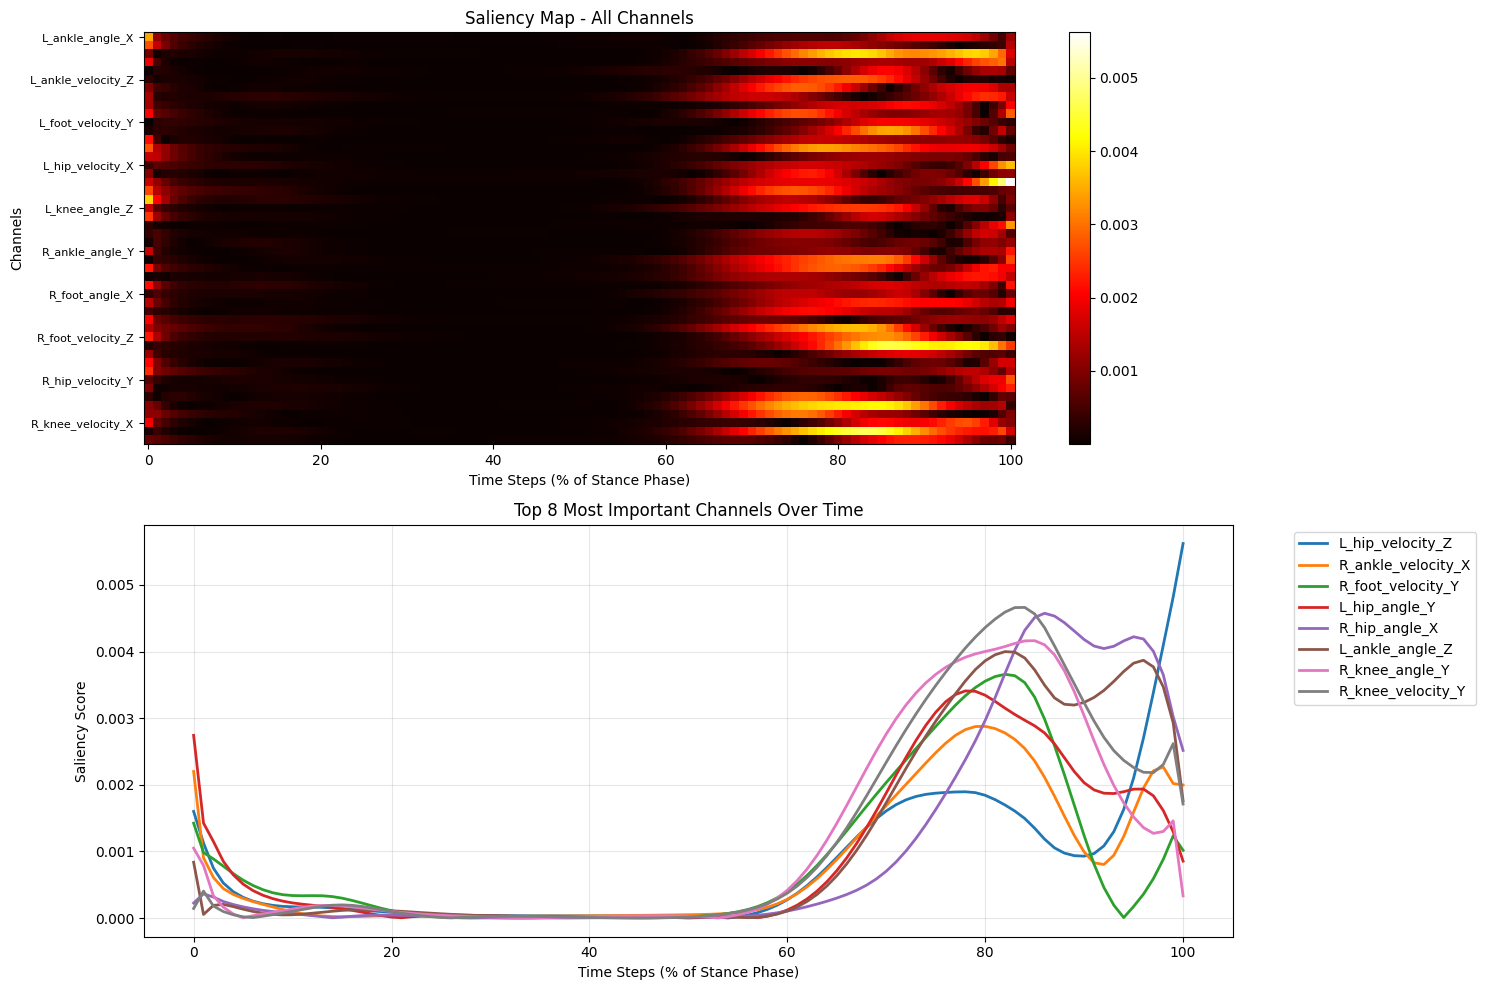

Injured sample saliency saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/saliency_injured_sample.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Compute saliency maps for injured sample
injured_ts = X_ts_test[injured_idx:injured_idx+1]
injured_meta = X_meta_test[injured_idx:injured_idx+1]

saliency_injured = compute_timeseries_saliency(model, injured_ts, injured_meta, target_class=1)
print(f"Injured sample - Actual: {y_test[injured_idx]}, Predicted: {(model.predict([injured_ts, injured_meta])[0,0] > 0.5).astype(int)}")

print("\n=== SALIENCY MAP: INJURED SAMPLE ===")
top_channels_injured, importance_injured = plot_timeseries_saliency(saliency_injured, channels, top_k=8)

# Save the plot
plt.savefig(RESULTS_DIR / 'saliency_injured_sample.png', dpi=300, bbox_inches='tight')
print(f"Injured sample saliency saved to: {RESULTS_DIR / 'saliency_injured_sample.png'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_46437/3356506134.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Healthy sample - Actual: {y_test[healthy_idx]}, Predicted: {(model.predict([healthy_ts, healthy_meta])[0,0] > 0.5).astype(int)}")


Healthy sample - Actual: False, Predicted: 1

=== SALIENCY MAP: HEALTHY SAMPLE ===


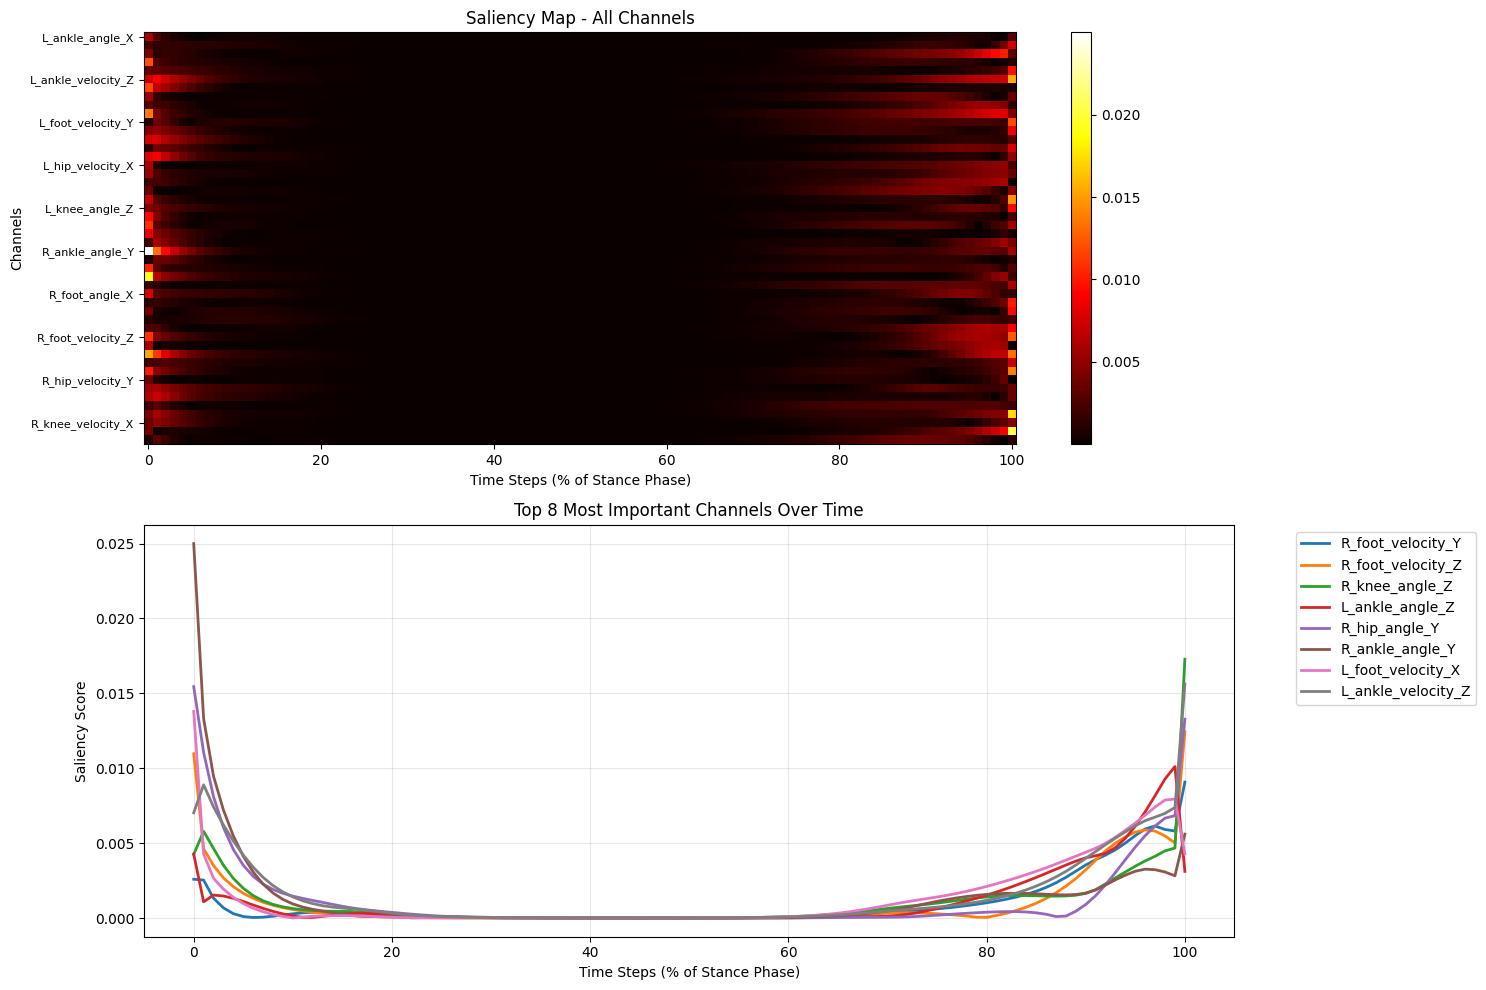

Healthy sample saliency saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/saliency_healthy_sample.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Compute saliency maps for healthy sample
healthy_ts = X_ts_test[healthy_idx:healthy_idx+1]
healthy_meta = X_meta_test[healthy_idx:healthy_idx+1]

saliency_healthy = compute_timeseries_saliency(model, healthy_ts, healthy_meta, target_class=0)
print(f"Healthy sample - Actual: {y_test[healthy_idx]}, Predicted: {(model.predict([healthy_ts, healthy_meta])[0,0] > 0.5).astype(int)}")

print("\n=== SALIENCY MAP: HEALTHY SAMPLE ===")
top_channels_healthy, importance_healthy = plot_timeseries_saliency(saliency_healthy, channels, top_k=8)

# Save the plot
plt.savefig(RESULTS_DIR / 'saliency_healthy_sample.png', dpi=300, bbox_inches='tight')
print(f"Healthy sample saliency saved to: {RESULTS_DIR / 'saliency_healthy_sample.png'}")


Analyzing 50 samples for global importance...

=== GLOBAL FEATURE IMPORTANCE ===


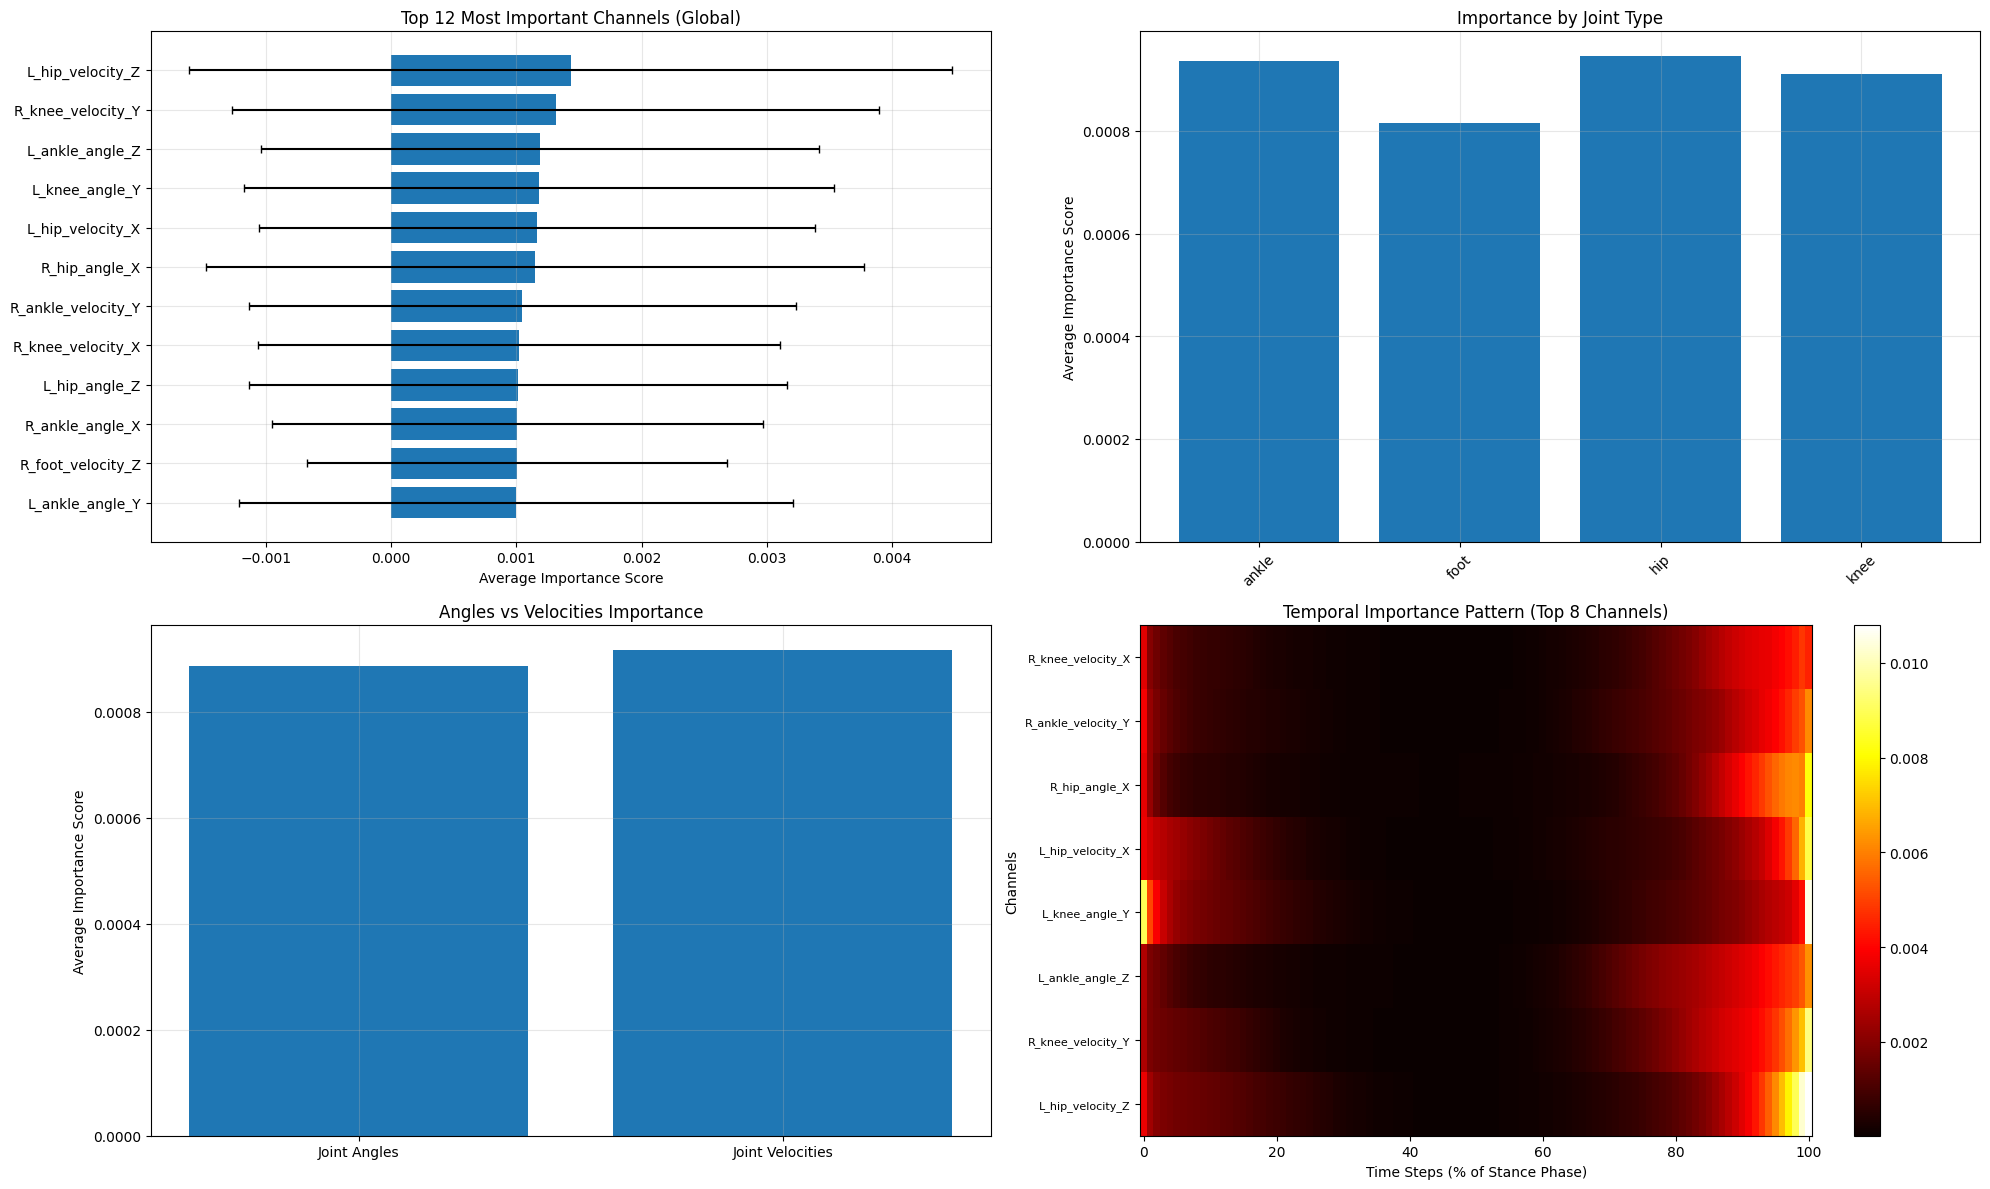

Global importance plot saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/global_feature_importance.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# Step 16: Global Feature Importance Analysis

def analyze_global_feature_importance(model, X_ts_sample, X_meta_sample, channels, n_samples=100):
    """
    Analyze global feature importance across multiple samples.
    
    Args:
        model: Trained model
        X_ts_sample: Sample of timeseries data
        X_meta_sample: Sample of metadata
        channels: Channel names
        n_samples: Number of samples to analyze
    
    Returns:
        Dictionary with importance statistics
    """
    
    n_samples = min(n_samples, len(X_ts_sample))
    all_saliencies = []
    
    print(f"Analyzing {n_samples} samples for global importance...")
    
    for i in range(n_samples):
        ts_input = X_ts_sample[i:i+1]
        meta_input = X_meta_sample[i:i+1]
        
        saliency = compute_timeseries_saliency(model, ts_input, meta_input)
        all_saliencies.append(saliency[0])  # Remove batch dimension
    
    all_saliencies = np.array(all_saliencies)  # Shape: (n_samples, 101, 48)
    
    # Calculate statistics
    mean_importance = np.mean(all_saliencies, axis=(0, 1))  # Average over samples and time
    std_importance = np.std(all_saliencies, axis=(0, 1))
    
    # Time-averaged importance for each channel
    temporal_importance = np.mean(all_saliencies, axis=0)  # Shape: (101, 48)
    
    return {
        'mean_importance': mean_importance,
        'std_importance': std_importance, 
        'temporal_importance': temporal_importance,
        'all_saliencies': all_saliencies,
        'channels': channels
    }

# Analyze global importance
global_importance = analyze_global_feature_importance(
    model, X_ts_test, X_meta_test, channels, n_samples=50
)

# Plot global feature importance
def plot_global_importance(importance_data, top_k=15):
    """Plot global feature importance analysis."""
    
    mean_imp = importance_data['mean_importance']
    std_imp = importance_data['std_importance']
    channels = importance_data['channels']
    temporal_imp = importance_data['temporal_importance']
    
    # Get top-k most important channels
    top_channels_idx = np.argsort(mean_imp)[-top_k:]
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    
    # Plot 1: Top channel importance with error bars
    y_pos = np.arange(len(top_channels_idx))
    axes[0, 0].barh(y_pos, mean_imp[top_channels_idx], 
                    xerr=std_imp[top_channels_idx], capsize=3)
    axes[0, 0].set_yticks(y_pos)
    axes[0, 0].set_yticklabels([channels[i] for i in top_channels_idx])
    axes[0, 0].set_xlabel('Average Importance Score')
    axes[0, 0].set_title(f'Top {top_k} Most Important Channels (Global)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Importance by joint type
    joint_importance = {}
    for i, channel in enumerate(channels):
        joint = channel.split('_')[1]  # Extract joint name (ankle, knee, etc.)
        if joint not in joint_importance:
            joint_importance[joint] = []
        joint_importance[joint].append(mean_imp[i])
    
    joint_means = {joint: np.mean(scores) for joint, scores in joint_importance.items()}
    joint_names = list(joint_means.keys())
    joint_scores = list(joint_means.values())
    
    axes[0, 1].bar(joint_names, joint_scores)
    axes[0, 1].set_ylabel('Average Importance Score')
    axes[0, 1].set_title('Importance by Joint Type')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Importance by measurement type (angle vs velocity)
    angle_indices = [i for i, ch in enumerate(channels) if 'angle' in ch]
    velocity_indices = [i for i, ch in enumerate(channels) if 'velocity' in ch]
    
    angle_importance = np.mean(mean_imp[angle_indices])
    velocity_importance = np.mean(mean_imp[velocity_indices])
    
    axes[1, 0].bar(['Joint Angles', 'Joint Velocities'], 
                   [angle_importance, velocity_importance])
    axes[1, 0].set_ylabel('Average Importance Score')
    axes[1, 0].set_title('Angles vs Velocities Importance')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Temporal importance heatmap for top channels
    temporal_top = temporal_imp[:, top_channels_idx[-8:]]  # Top 8 channels
    im = axes[1, 1].imshow(temporal_top.T, aspect='auto', cmap='hot')
    axes[1, 1].set_title('Temporal Importance Pattern (Top 8 Channels)')
    axes[1, 1].set_xlabel('Time Steps (% of Stance Phase)')
    axes[1, 1].set_ylabel('Channels')
    axes[1, 1].set_yticks(range(8))
    axes[1, 1].set_yticklabels([channels[i] for i in top_channels_idx[-8:]], fontsize=8)
    plt.colorbar(im, ax=axes[1, 1])
    
    plt.tight_layout()
    plt.show()
    
    return joint_importance, top_channels_idx

print("\n=== GLOBAL FEATURE IMPORTANCE ===")
joint_importance, top_global_channels = plot_global_importance(global_importance, top_k=12)

# Save the plot
plt.savefig(RESULTS_DIR / 'global_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"Global importance plot saved to: {RESULTS_DIR / 'global_feature_importance.png'}")


In [ ]:
# Step 17: SHAP Analysis for Metadata Features

def analyze_metadata_with_shap(model, X_meta_train, X_meta_test, X_ts_test, feature_names):
    """
    Use SHAP to explain metadata feature importance.
    
    Args:
        model: Trained model
        X_meta_train: Training metadata for background
        X_meta_test: Test metadata
        X_ts_test: Test timeseries (needed for model prediction)
        feature_names: Names of metadata features
    
    Returns:
        SHAP explainer and values
    """
    
    # Create a wrapper function for SHAP that handles both inputs
    def model_predict_meta(meta_data):
        """Predict using metadata, with mean timeseries as background."""
        n_samples = meta_data.shape[0]
        
        # Use mean timeseries as background for all predictions
        mean_ts = np.mean(X_ts_test, axis=0, keepdims=True)
        ts_background = np.tile(mean_ts, (n_samples, 1, 1))
        
        predictions = model.predict([ts_background, meta_data], verbose=0)
        return predictions.flatten()
    
    # Create SHAP explainer
    print("Creating SHAP explainer for metadata features...")
    background_meta = X_meta_train[:100]  # Use sample for background
    explainer = shap.KernelExplainer(model_predict_meta, background_meta)
    
    # Calculate SHAP values for test samples
    print("Computing SHAP values (this may take a few minutes)...")
    n_explain = min(50, len(X_meta_test))  # Limit for computational efficiency
    shap_values = explainer.shap_values(X_meta_test[:n_explain])
    
    return explainer, shap_values, feature_names

# Use the feature names from the preprocessing step
print(f"Using metadata feature names: {meta_feature_names}")

# Run SHAP analysis
print("\n=== SHAP ANALYSIS FOR METADATA ===")
shap_explainer, shap_values, feature_names = analyze_metadata_with_shap(
    model, X_meta_train, X_meta_test, X_ts_test, meta_feature_names
)


Using metadata feature names: ['age', 'Height', 'Weight', 'speed_r', 'Gender_female', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']

=== SHAP ANALYSIS FOR METADATA ===
Creating SHAP explainer for metadata features...
Computing SHAP values (this may take a few minutes)...


  0%|          | 0/50 [00:00<?, ?it/s]

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: invalid value encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)


In [ ]:
# Plot SHAP results
print("Creating SHAP visualizations...")

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_meta_test[:len(shap_values)], feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Metadata Features')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shap_summary_metadata.png', dpi=300, bbox_inches='tight')
plt.show()

# Bar plot of feature importance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_meta_test[:len(shap_values)], feature_names=feature_names, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Metadata Features')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'shap_bar_metadata.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"SHAP plots saved to: {RESULTS_DIR}")


In [ ]:
# Step 19: Activation Maximization (What patterns activate injury prediction?)

def find_optimal_input_pattern(model, target_class=1, iterations=1000, learning_rate=0.01):
    """
    Find the input pattern that maximally activates the injury prediction.
    
    This helps understand what the model has learned as "injury patterns".
    
    Args:
        model: Trained model
        target_class: Class to optimize for (1 for injury)
        iterations: Number of optimization steps
        learning_rate: Learning rate for optimization
    
    Returns:
        Optimized timeseries pattern
    """
    
    # Initialize random input
    optimal_ts = tf.Variable(tf.random.normal((1, 101, 48), stddev=0.1), dtype=tf.float32)
    
    # Use mean metadata as fixed input
    mean_meta = tf.constant(np.mean(X_meta_test, axis=0, keepdims=True), dtype=tf.float32)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    losses = []
    
    for i in range(iterations):
        with tf.GradientTape() as tape:
            predictions = model([optimal_ts, mean_meta])
            
            if target_class == 1:
                # Maximize probability of injury
                loss = -predictions[0, 0]
            else:
                # Maximize probability of no injury
                loss = predictions[0, 0]
            
            # Add regularization to keep values reasonable
            regularization = 0.01 * tf.reduce_mean(tf.square(optimal_ts))
            loss += regularization
        
        gradients = tape.gradient(loss, optimal_ts)
        optimizer.apply_gradients([(gradients, optimal_ts)])
        
        losses.append(loss.numpy())
        
        if i % 200 == 0:
            prob = model.predict([optimal_ts, mean_meta], verbose=0)[0, 0]
            print(f"Iteration {i}: Loss = {loss:.4f}, Injury Prob = {prob:.4f}")
    
    return optimal_ts.numpy(), losses

print("\n=== ACTIVATION MAXIMIZATION ===")
print("Finding optimal pattern that maximizes injury prediction...")

optimal_injury_pattern, optimization_losses = find_optimal_input_pattern(
    model, target_class=1, iterations=1000
)

# Plot the results
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# Plot 1: Optimization loss
axes[0, 0].plot(optimization_losses)
axes[0, 0].set_title('Optimization Loss Over Iterations')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Optimal pattern heatmap
im1 = axes[0, 1].imshow(optimal_injury_pattern[0].T, aspect='auto', cmap='RdBu_r')
axes[0, 1].set_title('Optimal Input Pattern for Injury Prediction')
axes[0, 1].set_xlabel('Time Steps (% of Stance Phase)')
axes[0, 1].set_ylabel('Channels')
axes[0, 1].set_yticks(range(0, len(channels), 5))
axes[0, 1].set_yticklabels([channels[i] for i in range(0, len(channels), 5)], fontsize=8)
plt.colorbar(im1, ax=axes[0, 1])

# Plot 3: Channel importance in optimal pattern
channel_importance_optimal = np.mean(np.abs(optimal_injury_pattern[0]), axis=0)
top_optimal_channels = np.argsort(channel_importance_optimal)[-12:]

y_pos = np.arange(len(top_optimal_channels))
axes[1, 0].barh(y_pos, channel_importance_optimal[top_optimal_channels])
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels([channels[i] for i in top_optimal_channels])
axes[1, 0].set_xlabel('Average Magnitude')
axes[1, 0].set_title('Most Important Channels in Optimal Pattern')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Temporal patterns for top channels
for i, ch_idx in enumerate(top_optimal_channels[-6:]):
    axes[1, 1].plot(optimal_injury_pattern[0, :, ch_idx], 
                    label=channels[ch_idx], linewidth=2)

axes[1, 1].set_title('Temporal Patterns in Top Channels')
axes[1, 1].set_xlabel('Time Steps (% of Stance Phase)')
axes[1, 1].set_ylabel('Activation Value')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the plot
plt.savefig(RESULTS_DIR / 'activation_maximization.png', dpi=300, bbox_inches='tight')
print(f"Activation maximization plot saved to: {RESULTS_DIR / 'activation_maximization.png'}")

# Final prediction for the optimal pattern
final_prob = model.predict([optimal_injury_pattern, np.mean(X_meta_test, axis=0, keepdims=True)], verbose=0)[0, 0]
print(f"\nFinal injury probability for optimal pattern: {final_prob:.4f}")
